DATATHON 2026 VERİ İNCELEME TEMİZLEME

In [ ]:
import pandas as pd

# Dosyaları oku
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test_x.csv")
sample = pd.read_csv("/content/sample_submission.csv")

# Boyutlar
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample shape:", sample.shape)

# İlk 5 satır
train.head()

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [ ]:
print(train.columns.tolist())

['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']


In [ ]:
train.isnull().sum().sort_values(ascending=False)

,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
yas,0
id,0
derin_uyku_yuzdesi,0
rem_yuzdesi,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

train = pd.read_csv("train.csv")
test = pd.read_csv("test_x.csv")
sample = pd.read_csv("sample_submission.csv")

target = "bilissel_performans_skoru"

X = train.drop(columns=[target])
y = train[target]

test_ids = test["id"]

# id modelden çıkar
X = X.drop(columns=["id"])
test_model = test.drop(columns=["id"])

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Sayısal sütunlar:", len(num_cols), num_cols)
print("Kategorik sütunlar:", len(cat_cols), cat_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=18,
        min_samples_leaf=2
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
        min_samples_leaf=1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=400,
        learning_rate=0.04,
        max_depth=4
    )
}

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    results[name] = {
        "rmse": rmse,
        "pipe": pipe
    }

    print(name, "RMSE:", rmse)

best_name = min(results, key=lambda x: results[x]["rmse"])
best_model = results[best_name]["pipe"]

print("En iyi model:", best_name)
print("En iyi RMSE:", results[best_name]["rmse"])
# En iyi modeli tüm train verisiyle yeniden eğit
best_model.fit(X, y)

final_preds = best_model.predict(test_model)

submission = pd.DataFrame({
    "id": test_ids,
    "bilissel_performans_skoru": final_preds
})

submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head()

Sayısal sütunlar: 15 ['yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat']
Kategorik sütunlar: 7 ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


KeyboardInterrupt: 

In [ ]:
print("Train satır/sütun:", train.shape)
print("Test satır/sütun:", test.shape)
print("Sample satır/sütun:", sample.shape)

print("\nTrain sütunları:")
print(train.columns.tolist())

print("\nTest sütunları:")
print(test.columns.tolist())

In [ ]:
target = "bilissel_performans_skoru"

num_cols = train.drop(columns=[target]).select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train.drop(columns=[target]).select_dtypes(include=["object"]).columns.tolist()

print("Sayısal sütun sayısı:", len(num_cols))
print(num_cols)

print("\nKategorik sütun sayısı:", len(cat_cols))
print(cat_cols)

In [ ]:
missing = train.isnull().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(train) * 100).round(2)

missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

In [ ]:
print(train["bilissel_performans_skoru"].describe())

In [ ]:
import matplotlib.pyplot as plt

train["bilissel_performans_skoru"].hist(bins=50)
plt.title("Hedef Değişken Dağılımı")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frekans")
plt.show()

In [ ]:
important_cols = [
    "vucut_kitle_indeksi",
    "stres_skoru",
    "uyku_oncesi_kafein_mg",
    "uyku_oncesi_ekran_suresi_dk",
    "gunluk_adim_sayisi",
    "uykuya_dalma_suresi_dk",
    "gecelik_uyanma_sayisi"
]

train[important_cols].describe()

In [ ]:
import matplotlib.pyplot as plt

for col in important_cols:
    plt.figure(figsize=(8,3))
    train.boxplot(column=col)
    plt.title(col)
    plt.show()

In [ ]:
numeric_train = train.select_dtypes(include=["int64", "float64"])

corr_target = numeric_train.corr()["bilissel_performans_skoru"].sort_values(ascending=False)

corr_target

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_corr_cols = corr_target.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(12,8))
sns.heatmap(train[top_corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Top Korelasyonlar")
plt.show()

In [ ]:
import numpy as np

# Uyku kalitesi
train["uyku_kalite_skoru"] = train["rem_yuzdesi"] + train["derin_uyku_yuzdesi"]

# Uyku bozulması
train["uyku_bozulma_skoru"] = train["uykuya_dalma_suresi_dk"] + (train["gecelik_uyanma_sayisi"] * 5)

# Dijital yük
train["dijital_yuk"] = train["uyku_oncesi_ekran_suresi_dk"] + np.log1p(train["uyku_oncesi_kafein_mg"])

# Fiziksel sağlık
train["fiziksel_saglik"] = train["gunluk_adim_sayisi"] / train["vucut_kitle_indeksi"]

# İş yükü x stres
train["is_stres_yuku"] = train["gunluk_calisma_saati"] * train["stres_skoru"]

# REM / stres dengesi
train["rem_stres_denge"] = train["rem_yuzdesi"] / (train["stres_skoru"] + 1)

# Yaş etkisi
train["yas_kare"] = train["yas"] ** 2

In [ ]:
test["uyku_kalite_skoru"] = test["rem_yuzdesi"] + test["derin_uyku_yuzdesi"]
test["uyku_bozulma_skoru"] = test["uykuya_dalma_suresi_dk"] + (test["gecelik_uyanma_sayisi"] * 5)
test["dijital_yuk"] = test["uyku_oncesi_ekran_suresi_dk"] + np.log1p(test["uyku_oncesi_kafein_mg"])
test["fiziksel_saglik"] = test["gunluk_adim_sayisi"] / test["vucut_kitle_indeksi"]
test["is_stres_yuku"] = test["gunluk_calisma_saati"] * test["stres_skoru"]
test["rem_stres_denge"] = test["rem_yuzdesi"] / (test["stres_skoru"] + 1)
test["yas_kare"] = test["yas"] ** 2

In [ ]:
new_corr = train.corr(numeric_only=True)["bilissel_performans_skoru"].sort_values(ascending=False)

new_corr.head(20)

In [ ]:
drop_cols = ["id"]

X = train.drop(columns=drop_cols + ["bilissel_performans_skoru"])
y = train["bilissel_performans_skoru"]

X_test_final = test.drop(columns=drop_cols)

In [ ]:
!pip install catboost -q

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
# Kopya alalım
X = X.copy()
X_test_final = X_test_final.copy()

# Kategorik ve sayısal sütunları tekrar belirle
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Kategorik eksikler
for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test_final[col] = X_test_final[col].fillna("Unknown").astype(str)

# Sayısal eksikler
for col in num_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    X_test_final[col] = X_test_final[col].fillna(median_value)

print("Kategorik sütunlar:", cat_cols)
print("Train eksik toplam:", X.isnull().sum().sum())
print("Test eksik toplam:", X_test_final.isnull().sum().sum())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
cat_model = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_val, y_val),
    use_best_model=True
)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

val_preds = cat_model.predict(X_val)
val_preds = np.clip(val_preds, 0, 10)

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("Validation RMSE:", rmse)

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(25)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for train_idx, val_idx in kf.split(X):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=900,
        depth=8,
        learning_rate=0.03,
        loss_function="RMSE",
        verbose=0,
        random_seed=42
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=cat_cols
    )

    preds = np.clip(model.predict(X_va), 0, 10)

    rmse = np.sqrt(mean_squared_error(y_va, preds))
    rmse_scores.append(rmse)

print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", np.mean(rmse_scores))

In [ ]:
!pip install catboost -q

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test_x.csv")

target = "bilissel_performans_skoru"

# Feature engineering fonksiyonu
def add_features(df):
    df = df.copy()
    df["uyku_kalite_skoru"] = df["rem_yuzdesi"] + df["derin_uyku_yuzdesi"]
    df["uyku_bozulma_skoru"] = df["uykuya_dalma_suresi_dk"] + (df["gecelik_uyanma_sayisi"] * 5)
    df["dijital_yuk"] = df["uyku_oncesi_ekran_suresi_dk"] + np.log1p(df["uyku_oncesi_kafein_mg"])
    df["fiziksel_saglik"] = df["gunluk_adim_sayisi"] / df["vucut_kitle_indeksi"]
    df["is_stres_yuku"] = df["gunluk_calisma_saati"] * df["stres_skoru"]
    df["rem_stres_denge"] = df["rem_yuzdesi"] / (df["stres_skoru"] + 1)
    df["yas_kare"] = df["yas"] ** 2
    return df

train = add_features(train)
test = add_features(test)

test_ids = test["id"]

X = train.drop(columns=["id", target])
y = train[target]
X_test = test.drop(columns=["id"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

for col in num_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

cat_model = CatBoostRegressor(
    iterations=900,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X,
    y,
    cat_features=cat_cols
)

final_preds = cat_model.predict(X_test)
final_preds = np.clip(final_preds, 0, 10)

submission = pd.DataFrame({
    "id": test_ids,
    "bilissel_performans_skoru": final_preds
})

submission.to_csv("submission_catboost.csv", index=False)

print(submission.shape)
submission.head()

son çalışma:Kategorik değişkenlerin hedef üzerindeki gerçek etkisini ölçme


In [ ]:
target = "bilissel_performans_skoru"

important_cat_cols = [
    "ruh_sagligi_durumu",
    "kronotip",
    "gun_tipi",
    "meslek",
    "ulke"
]

for col in important_cat_cols:
    print("\n" + "="*60)
    print(f"KATEGORİ: {col}")

    display(
        train.groupby(col, dropna=False)[target]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )


KATEGORİ: ruh_sagligi_durumu


,count,mean,std,min,max
ruh_sagligi_durumu,,,,,
Saglikli,38365,6.491822,2.018310,0.0,10.000000
NaN,1096,5.939361,2.184929,0.0,10.000000
Anksiyete,8270,5.012262,2.097732,0.0,10.000000
Depresyon,5504,4.394400,2.011677,0.0,9.674794
Anksiyete ve depresyon,2765,3.590186,2.046661,0.0,9.389999



KATEGORİ: kronotip


,count,mean,std,min,max
kronotip,,,,,
NaN,1968,6.016487,2.231868,0.0,10.0
Sabah insani,13500,5.995613,2.230439,0.0,10.0
Notr,24594,5.934548,2.227339,0.0,10.0
Gece insani,15938,5.797330,2.235135,0.0,10.0



KATEGORİ: gun_tipi


,count,mean,std,min,max
gun_tipi,,,,,
Hafta sonu,15948,6.993307,1.938364,0.0,10.0
Hafta ici,40052,5.482975,2.195082,0.0,10.0



KATEGORİ: meslek


,count,mean,std,min,max
meslek,,,,,
Emekli,3778,7.935044,1.608945,0.946770,10.0
Ev Hanimi,3224,7.055969,1.802786,0.000000,10.0
Serbest Calisan,3812,6.985534,1.870769,0.010578,10.0
Egitimci,4395,6.343725,2.011186,0.000000,10.0
Muhendis,6533,6.223087,2.040621,0.000000,10.0
NaN,1378,6.022928,2.309071,0.000000,10.0
Satis ve Pazarlama Calisani,3899,6.010286,2.055236,0.000000,10.0
Yonetici,4454,5.729820,2.127878,0.000000,10.0
Ogrenci,8132,5.535248,2.111092,0.000000,10.0



KATEGORİ: ulke


,count,mean,std,min,max
ulke,,,,,
Spain,1139,5.990125,2.258548,0.0,10.0
Isvec,2798,5.982263,2.232869,0.0,10.0
Netherlands,1707,5.974815,2.225807,0.0,10.0
Mexico,2165,5.951125,2.243415,0.0,10.0
Ispanya,2823,5.924855,2.254054,0.0,10.0
Yeni Zelanda,2777,5.920415,2.192501,0.0,10.0
Ingiltere,11324,5.915436,2.247550,0.0,10.0
Cin,9989,5.912783,2.234246,0.0,10.0
Guney Kore,4459,5.909655,2.208531,0.0,10.0


Kategori bazlı mean encoding oluştur

Amaç: Kategorileri sadece text değil, “bu kategori ortalama kaç skor getiriyor” olarak modele öğretmek.

In [ ]:
high_signal_cols = [
    "meslek",
    "ruh_sagligi_durumu",
    "kronotip",
    "gun_tipi"
]

for col in high_signal_cols:
    mean_map = train.groupby(col)[target].mean()

    train[f"{col}_mean_target"] = train[col].map(mean_map)
    test[f"{col}_mean_target"] = test[col].map(mean_map)

    # testte unseen varsa global mean
    global_mean = train[target].mean()
    test[f"{col}_mean_target"] = test[f"{col}_mean_target"].fillna(global_mean)

print("Yeni mean target featurelar eklendi:")
print([f"{col}_mean_target" for col in high_signal_cols])

Yeni mean target featurelar eklendi:
['meslek_mean_target', 'ruh_sagligi_durumu_mean_target', 'kronotip_mean_target', 'gun_tipi_mean_target']


Bu yeni featurelar gerçekten güçlü mü kontrol edelim

Amaç: Mean target feature ekledik ama gerçekten hedefle güçlü korelasyon veriyor mu bakacağız.
Eğer burada 0.7–0.95 gibi değerler görürsek çok büyük avantaj olabilir.

In [ ]:
new_features = [f"{col}_mean_target" for col in high_signal_cols]

corr_check = train[new_features + [target]].corr(numeric_only=True)[target].sort_values(ascending=False)

print("Yeni feature korelasyonları:")
print(corr_check)

Yeni feature korelasyonları:
bilissel_performans_skoru         1.000000
ruh_sagligi_durumu_mean_target    0.415171
meslek_mean_target                0.396278
gun_tipi_mean_target              0.305426
kronotip_mean_target              0.034272
Name: bilissel_performans_skoru, dtype: float64


Hücre 4 — Combo feature üret

Amaç: İki güçlü kategoriyi birleştirip daha spesifik pattern yakalamak.
Ruh sağlığı + meslek birleşimi

Örn:

Sağlıklı + Emekli
Anksiyete + Öğrenci

Bu birleşim tek başına çok daha keskin segment yaratabilir.

In [ ]:
train["meslek_ruh_combo"] = (
    train["meslek"].astype(str) + "_" + train["ruh_sagligi_durumu"].astype(str)
)

test["meslek_ruh_combo"] = (
    test["meslek"].astype(str) + "_" + test["ruh_sagligi_durumu"].astype(str)
)

combo_mean = train.groupby("meslek_ruh_combo")[target].mean()

train["meslek_ruh_combo_mean_target"] = train["meslek_ruh_combo"].map(combo_mean)
test["meslek_ruh_combo_mean_target"] = test["meslek_ruh_combo"].map(combo_mean)

global_mean = train[target].mean()
test["meslek_ruh_combo_mean_target"] = test["meslek_ruh_combo_mean_target"].fillna(global_mean)

print("Combo feature eklendi.")

Combo feature eklendi.


Hücre 5 — Combo feature gerçekten bomba mı kontrol edelim

Amaç: Yeni oluşturduğumuz meslek + ruh sağlığı birleşimi gerçekten tek başına daha güçlü mü bakacağız.
Eğer bu değer 0.45+ gelirse ciddi kazanım olabilir.

In [ ]:
check_cols = [
    target,
    "meslek_mean_target",
    "ruh_sagligi_durumu_mean_target",
    "meslek_ruh_combo_mean_target"
]

combo_corr = train[check_cols].corr(numeric_only=True)[target].sort_values(ascending=False)

print("Combo feature karşılaştırma:")
print(combo_corr)

Combo feature karşılaştırma:
bilissel_performans_skoru         1.000000
meslek_ruh_combo_mean_target      0.567700
ruh_sagligi_durumu_mean_target    0.415171
meslek_mean_target                0.396278
Name: bilissel_performans_skoru, dtype: float64


Model artık sadece:

Öğrenci
Sağlıklı

değil,

“Öğrenci + Anksiyete”
“Emekli + Sağlıklı”

gibi çok daha spesifik grupları öğrenebiliyor.

Hücre 6 — Ultra combo feature

Amaç: Daha mikro segment.

In [ ]:
train["ultra_combo"] = (
    train["meslek"].astype(str) + "_" +
    train["ruh_sagligi_durumu"].astype(str) + "_" +
    train["gun_tipi"].astype(str)
)

test["ultra_combo"] = (
    test["meslek"].astype(str) + "_" +
    test["ruh_sagligi_durumu"].astype(str) + "_" +
    test["gun_tipi"].astype(str)
)

ultra_mean = train.groupby("ultra_combo")[target].mean()

train["ultra_combo_mean_target"] = train["ultra_combo"].map(ultra_mean)
test["ultra_combo_mean_target"] = test["ultra_combo"].map(ultra_mean)

global_mean = train[target].mean()
test["ultra_combo_mean_target"] = test["ultra_combo_mean_target"].fillna(global_mean)

print("Ultra combo feature eklendi.")

Ultra combo feature eklendi.


Hücre 7 — Ultra combo gerçekten daha da güçlü mü bakalım

Amaç: Eğer ultra_combo_mean_target değeri 0.60+ çıkarsa bu şu ana kadarki en kritik feature olabilir.

In [ ]:
ultra_check_cols = [
    target,
    "meslek_ruh_combo_mean_target",
    "ultra_combo_mean_target"
]

ultra_corr = train[ultra_check_cols].corr(numeric_only=True)[target].sort_values(ascending=False)

print("Ultra combo karşılaştırma:")
print(ultra_corr)

Ultra combo karşılaştırma:
bilissel_performans_skoru       1.000000
ultra_combo_mean_target         0.655346
meslek_ruh_combo_mean_target    0.567700
Name: bilissel_performans_skoru, dtype: float64


Yeni strateji:
CatBoost + engineered + target mean + ultra combo
Hücre 8 — Final model için feature set hazırlığı

Amaç: Şu an oluşturduğumuz tüm güçlü featureları train/test içine bırakıp CatBoost’a hazır hale getirmek.

In [ ]:
# id varsa çıkar
if "id" in train.columns:
    train_model = train.drop(columns=["id", target])
else:
    train_model = train.drop(columns=[target])

if "id" in test.columns:
    test_model = test.drop(columns=["id"])
else:
    test_model = test.copy()

y = train[target]

cat_cols_final = train_model.select_dtypes(include="object").columns.tolist()

print("Train shape:", train_model.shape)
print("Test shape:", test_model.shape)
print("Kategorik sütun sayısı:", len(cat_cols_final))

Train shape: (56000, 30)
Test shape: (24000, 30)
Kategorik sütun sayısı: 9


Hücre 9 — Final veri sağlık kontrolü

In [ ]:
import numpy as np

# Infinity değerleri NaN yap
train_model = train_model.replace([np.inf, -np.inf], np.nan)
test_model = test_model.replace([np.inf, -np.inf], np.nan)

# Null kontrol
train_nulls = train_model.isnull().sum().sort_values(ascending=False)
test_nulls = test_model.isnull().sum().sort_values(ascending=False)

print("TRAIN NULL TOPLAM:", train_nulls.sum())
print("TEST NULL TOPLAM:", test_nulls.sum())

print("\nTrain null olan sütunlar:")
print(train_nulls[train_nulls > 0])

print("\nTest null olan sütunlar:")
print(test_nulls[test_nulls > 0])

TRAIN NULL TOPLAM: 13814
TEST NULL TOPLAM: 4068

Train null olan sütunlar:
kronotip_mean_target              1968
kronotip                          1968
vucut_kitle_indeksi               1752
stres_skoru                       1715
uyku_oncesi_kafein_mg             1463
meslek                            1378
meslek_mean_target                1378
ruh_sagligi_durumu                1096
ruh_sagligi_durumu_mean_target    1096
dtype: int64

Test null olan sütunlar:
kronotip                 832
stres_skoru              765
uyku_oncesi_kafein_mg    697
vucut_kitle_indeksi      648
meslek                   622
ruh_sagligi_durumu       504
dtype: int64


Hücre 10 — Final temizlik

In [ ]:
# Kategorik sütunlar
cat_cols_final = train_model.select_dtypes(include="object").columns.tolist()

# Sayısal sütunlar
num_cols_final = train_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Kategorik doldur
for col in cat_cols_final:
    train_model[col] = train_model[col].fillna("Unknown")
    test_model[col] = test_model[col].fillna("Unknown")

# Sayısal doldur
for col in num_cols_final:
    median_val = train_model[col].median()
    train_model[col] = train_model[col].fillna(median_val)
    test_model[col] = test_model[col].fillna(median_val)

print("Final null kontrol:")
print("Train:", train_model.isnull().sum().sum())
print("Test:", test_model.isnull().sum().sum())

Final null kontrol:
Train: 0
Test: 0


Hücre 11 — Önce ana train/test’i temizle (EN BAŞTAN)

Bunu çalıştırınca featureları temiz veri üstünde tekrar kuracağız.

In [ ]:
# Orijinal dosyaları yeniden yükle
train = pd.read_csv("train.csv")
test = pd.read_csv("test_x.csv")

target = "bilissel_performans_skoru"

# Kategorik / sayısal sütunlar
cat_cols = train.drop(columns=[target]).select_dtypes(include="object").columns.tolist()
num_cols = train.drop(columns=[target]).select_dtypes(include=["int64", "float64"]).columns.tolist()

# Train temizliği
for col in cat_cols:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

print("RESET sonrası null:")
print("Train:", train.isnull().sum().sum())
print("Test:", test.isnull().sum().sum())

RESET sonrası null:
Train: 0
Test: 0


Hücre 12 — Engineered Features (Temiz versiyon)

In [ ]:
# Uyku kalite
train["uyku_kalite_skoru"] = train["rem_yuzdesi"] + train["derin_uyku_yuzdesi"]
test["uyku_kalite_skoru"] = test["rem_yuzdesi"] + test["derin_uyku_yuzdesi"]

# Uyku bozulması
train["uyku_bozulma_skoru"] = train["uykuya_dalma_suresi_dk"] + (train["gecelik_uyanma_sayisi"] * 5)
test["uyku_bozulma_skoru"] = test["uykuya_dalma_suresi_dk"] + (test["gecelik_uyanma_sayisi"] * 5)

# Dijital yük
train["dijital_yuk"] = train["uyku_oncesi_ekran_suresi_dk"] + np.log1p(train["uyku_oncesi_kafein_mg"])
test["dijital_yuk"] = test["uyku_oncesi_ekran_suresi_dk"] + np.log1p(test["uyku_oncesi_kafein_mg"])

# Fiziksel sağlık
train["fiziksel_saglik"] = train["gunluk_adim_sayisi"] / train["vucut_kitle_indeksi"]
test["fiziksel_saglik"] = test["gunluk_adim_sayisi"] / test["vucut_kitle_indeksi"]

# İş stres
train["is_stres_yuku"] = train["gunluk_calisma_saati"] * train["stres_skoru"]
test["is_stres_yuku"] = test["gunluk_calisma_saati"] * test["stres_skoru"]

# REM / stres
train["rem_stres_denge"] = train["rem_yuzdesi"] / (train["stres_skoru"] + 1)
test["rem_stres_denge"] = test["rem_yuzdesi"] / (test["stres_skoru"] + 1)

# Yaş etkisi
train["yas_kare"] = train["yas"] ** 2
test["yas_kare"] = test["yas"] ** 2

print("Engineered features tamam.")

Engineered features tamam.


Hücre 13 — Target Mean Encoding (Temiz veri sonrası yeniden

In [ ]:
high_signal_cols = [
    "meslek",
    "ruh_sagligi_durumu",
    "kronotip",
    "gun_tipi"
]

global_mean = train[target].mean()

for col in high_signal_cols:
    mean_map = train.groupby(col)[target].mean()

    train[f"{col}_mean_target"] = train[col].map(mean_map)
    test[f"{col}_mean_target"] = test[col].map(mean_map)

    # Güvenlik
    train[f"{col}_mean_target"] = train[f"{col}_mean_target"].fillna(global_mean)
    test[f"{col}_mean_target"] = test[f"{col}_mean_target"].fillna(global_mean)

print("Target mean encoding tamamlandı.")

Target mean encoding tamamlandı.


Hücre 14 — Combo + Ultra Combo (En kritik featurelar)

In [ ]:
# Meslek + ruh sağlığı combo
train["meslek_ruh_combo"] = train["meslek"].astype(str) + "_" + train["ruh_sagligi_durumu"].astype(str)
test["meslek_ruh_combo"] = test["meslek"].astype(str) + "_" + test["ruh_sagligi_durumu"].astype(str)

combo_map = train.groupby("meslek_ruh_combo")[target].mean()

train["meslek_ruh_combo_mean_target"] = train["meslek_ruh_combo"].map(combo_map)
test["meslek_ruh_combo_mean_target"] = test["meslek_ruh_combo"].map(combo_map)

train["meslek_ruh_combo_mean_target"] = train["meslek_ruh_combo_mean_target"].fillna(global_mean)
test["meslek_ruh_combo_mean_target"] = test["meslek_ruh_combo_mean_target"].fillna(global_mean)


# Ultra combo (meslek + ruh + gun tipi)
train["ultra_combo"] = (
    train["meslek"].astype(str) + "_" +
    train["ruh_sagligi_durumu"].astype(str) + "_" +
    train["gun_tipi"].astype(str)
)

test["ultra_combo"] = (
    test["meslek"].astype(str) + "_" +
    test["ruh_sagligi_durumu"].astype(str) + "_" +
    test["gun_tipi"].astype(str)
)

ultra_map = train.groupby("ultra_combo")[target].mean()

train["ultra_combo_mean_target"] = train["ultra_combo"].map(ultra_map)
test["ultra_combo_mean_target"] = test["ultra_combo"].map(ultra_map)

train["ultra_combo_mean_target"] = train["ultra_combo_mean_target"].fillna(global_mean)
test["ultra_combo_mean_target"] = test["ultra_combo_mean_target"].fillna(global_mean)

print("Combo + Ultra Combo hazır.")

Combo + Ultra Combo hazır.


Hücre 15 — Final CatBoost Model (Ana saldırı modeli)

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# id çıkar
train_model = train.drop(columns=[target, "id"], errors="ignore")
test_model = test.drop(columns=["id"], errors="ignore")

y = train[target]

cat_cols_final = train_model.select_dtypes(include="object").columns.tolist()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_rmse = []

for fold, (train_idx, val_idx) in enumerate(kf.split(train_model), 1):
    X_train_fold = train_model.iloc[train_idx]
    X_val_fold = train_model.iloc[val_idx]

    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=3000,
        depth=10,
        learning_rate=0.02,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=500
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        cat_features=cat_cols_final,
        eval_set=(X_val_fold, y_val_fold),
        use_best_model=True
    )

    preds = model.predict(X_val_fold)
    preds = np.clip(preds, 0, 10)

    rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
    fold_rmse.append(rmse)

    print(f"Fold {fold} RMSE:", rmse)

print("Mean RMSE:", np.mean(fold_rmse))

0:	learn: 2.2018705	test: 2.2131453	best: 2.2131453 (0)	total: 256ms	remaining: 12m 47s
500:	learn: 1.1441898	test: 1.2253975	best: 1.2253975 (500)	total: 1m 49s	remaining: 9m 4s
1000:	learn: 1.0668002	test: 1.2227130	best: 1.2227130 (1000)	total: 3m 39s	remaining: 7m 17s
1500:	learn: 1.0000640	test: 1.2226282	best: 1.2223619 (1111)	total: 5m 26s	remaining: 5m 26s
2000:	learn: 0.9357635	test: 1.2238262	best: 1.2223619 (1111)	total: 7m 14s	remaining: 3m 36s
2500:	learn: 0.8738323	test: 1.2253905	best: 1.2223619 (1111)	total: 9m 3s	remaining: 1m 48s
2999:	learn: 0.8198319	test: 1.2270640	best: 1.2223619 (1111)	total: 10m 51s	remaining: 0us

bestTest = 1.222361881
bestIteration = 1111

Shrink model to first 1112 iterations.
Fold 1 RMSE: 1.2223511377081417
0:	learn: 2.2061879	test: 2.1972128	best: 2.1972128 (0)	total: 196ms	remaining: 9m 46s
500:	learn: 1.1437380	test: 1.2223392	best: 1.2223392 (500)	total: 1m 43s	remaining: 8m 38s
1000:	learn: 1.0627884	test: 1.2210728	best: 1.2205859 (77

Hücre 1 — Dosyaları oku ve temel kontrol

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test_x.csv")

target = "bilissel_performans_skoru"

print(train.shape)
print(test.shape)
print(train.isnull().sum().sum(), test.isnull().sum().sum())

(56000, 24)
(24000, 23)
9372 4068


Hücre 2 — Hedef dağılımı ve korelasyon

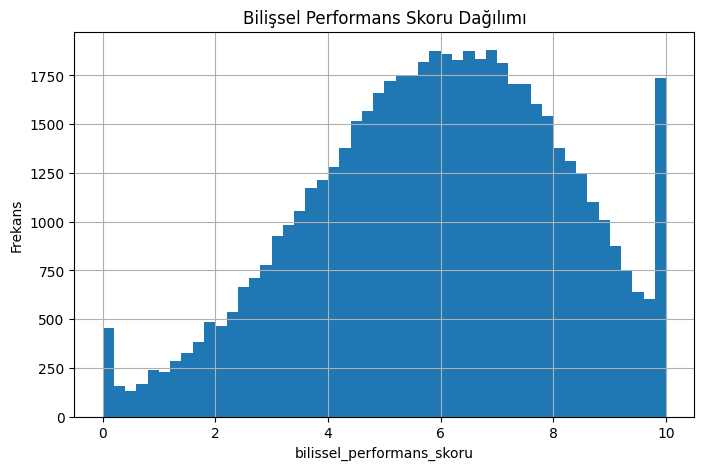

,bilissel_performans_skoru
bilissel_performans_skoru,1.000000
rem_yuzdesi,0.442999
derin_uyku_yuzdesi,0.280006
gunluk_adim_sayisi,0.134042
hafta_sonu_uyku_farki_saat,-0.001648
id,-0.005845
oda_sicakligi_celsius,-0.011992
sekerleme_suresi_dk,-0.023683
vucut_kitle_indeksi,-0.037990
uyku_oncesi_ekran_suresi_dk,-0.044631


In [ ]:
plt.figure(figsize=(8, 5))
train[target].hist(bins=50)
plt.title("Bilişsel Performans Skoru Dağılımı")
plt.xlabel(target)
plt.ylabel("Frekans")
plt.show()

corr_target = train.select_dtypes(include=["int64", "float64"]).corr()[target].sort_values(ascending=False)
corr_target

Hücre 3 — Kategori etkilerini incele

In [ ]:
important_cat_cols = [
    "meslek",
    "ruh_sagligi_durumu",
    "kronotip",
    "gun_tipi"
]

for col in important_cat_cols:
    print("\n" + "="*50)
    print(col)
    display(
        train.groupby(col, dropna=False)[target]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
    )


meslek


,count,mean,std,min,max
meslek,,,,,
Emekli,3778,7.935044,1.608945,0.946770,10.0
Ev Hanimi,3224,7.055969,1.802786,0.000000,10.0
Serbest Calisan,3812,6.985534,1.870769,0.010578,10.0
Egitimci,4395,6.343725,2.011186,0.000000,10.0
Muhendis,6533,6.223087,2.040621,0.000000,10.0
NaN,1378,6.022928,2.309071,0.000000,10.0
Satis ve Pazarlama Calisani,3899,6.010286,2.055236,0.000000,10.0
Yonetici,4454,5.729820,2.127878,0.000000,10.0
Ogrenci,8132,5.535248,2.111092,0.000000,10.0



ruh_sagligi_durumu


,count,mean,std,min,max
ruh_sagligi_durumu,,,,,
Saglikli,38365,6.491822,2.018310,0.0,10.000000
NaN,1096,5.939361,2.184929,0.0,10.000000
Anksiyete,8270,5.012262,2.097732,0.0,10.000000
Depresyon,5504,4.394400,2.011677,0.0,9.674794
Anksiyete ve depresyon,2765,3.590186,2.046661,0.0,9.389999



kronotip


,count,mean,std,min,max
kronotip,,,,,
NaN,1968,6.016487,2.231868,0.0,10.0
Sabah insani,13500,5.995613,2.230439,0.0,10.0
Notr,24594,5.934548,2.227339,0.0,10.0
Gece insani,15938,5.797330,2.235135,0.0,10.0



gun_tipi


,count,mean,std,min,max
gun_tipi,,,,,
Hafta sonu,15948,6.993307,1.938364,0.0,10.0
Hafta ici,40052,5.482975,2.195082,0.0,10.0
